# Load Dataset

The dataset is provided as an Excel workbook with multiple sheets.
Each sheet contains transactions from a different period.

In this step, we:
- Imported required libraries.
- Loaded the workbook.
- Verified the available sheets.
- Combined all sheets into a single DataFrame for analysis.

In [3]:
import pandas as pd
import numpy as np

In [5]:
file_path = "online_retail_store_data.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [6]:
all_sheets = pd.read_excel(
    file_path,
    sheet_name=None
)

In [8]:
type(all_sheets)
all_sheets.keys()

dict_keys(['Year 2009-2010', 'Year 2010-2011'])

In [11]:
df = pd.concat(
    all_sheets.values(),
    ignore_index=True
)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [15]:
df.shape

(1067371, 8)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [17]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [18]:
df.describe(include="object")

,Invoice,StockCode,Description,Country
count,1067371,1067371,1062989,1067371
unique,53628,5305,5698,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1350,5829,5918,981330


In [19]:
missing = df.isnull().sum().to_frame(name="Missing Values")
missing["Percentage"] = (missing["Missing Values"] / len(df) * 100).round(2)
missing

,Missing Values,Percentage
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [20]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 34335


In [21]:
df["Customer ID"].nunique()

5942

In [22]:
df["StockCode"].nunique()

5305

In [27]:
df["Country"].value_counts().head(10)

,count
Country,
United Kingdom,981330
EIRE,17866
Germany,17624
France,14330
Netherlands,5140
Spain,3811
Switzerland,3189
Belgium,3123
Portugal,2620


In [26]:
df["Country"].nunique()

43

In [28]:
negative_quantity = df[df["Quantity"] < 0]

print("Rows with negative quantity:", len(negative_quantity))

negative_quantity.head(10)

Rows with negative quantity: 22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [29]:
negative_price = df[df["Price"] < 0]

print("Rows with negative price:", len(negative_price))

negative_price

Rows with negative price: 5


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [30]:
zero_price = df[df["Price"] == 0]

print("Rows with zero price:", len(zero_price))

zero_price.head()

Rows with zero price: 6202


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


In [31]:
missing_customer = df[df["Customer ID"].isna()]

missing_customer.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [32]:
cancelled = df[df["Invoice"].astype(str).str.startswith("C")]

print("Cancelled invoices:", len(cancelled))

cancelled.head()

Cancelled invoices: 19494


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [33]:
negative_without_c = df[
    (df["Quantity"] < 0) &
    (~df["Invoice"].astype(str).str.startswith("C"))
]

print(negative_without_c.shape)

negative_without_c.head(20)

(3457, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [35]:
zero_price = df[df["Price"] == 0]

zero_price.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,6202.0,6202.0,1820,6202.000000,6202,6202.0,71.000000,6202
unique,5379.0,2971.0,612,NaN,NaN,NaN,NaN,11
top,537534.0,22501.0,check,NaN,NaN,NaN,NaN,United Kingdom
freq,114.0,18.0,162,NaN,NaN,NaN,NaN,6174
mean,NaN,NaN,NaN,-51.729442,2010-10-29 20:21:37.961947648,0.0,14211.802817,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 10:52:00,0.0,12415.000000,NaN
25%,NaN,NaN,NaN,-32.000000,2010-05-10 15:52:00,0.0,12697.500000,NaN
50%,NaN,NaN,NaN,-2.000000,2010-10-25 15:20:30,0.0,13985.000000,NaN
75%,NaN,NaN,NaN,3.000000,2011-04-20 12:04:15,0.0,15088.500000,NaN
max,NaN,NaN,NaN,12540.000000,2011-12-08 15:24:00,0.0,18071.000000,NaN


In [36]:
zero_price["Description"].value_counts().head(20)

,count
Description,
check,162
?,92
damages,84
damaged,81
found,28
missing,27
sold as set on dotcom,20
Damaged,17
adjustment,16


In [37]:
df[df.duplicated()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


In [66]:
print(f"Original Shape: {df.shape}")
df_clean = df.copy()

Original Shape: (1067371, 8)


In [78]:
cleaning_log = []
previous_rows = len(df_clean)

def log_cleaning_step(step_name, dataframe, reason):
    global previous_rows

    current_rows = len(dataframe)

    cleaning_log.append({
        "Step": step_name,
        "Reason": reason,
        "Rows Remaining": current_rows,
        "Rows Removed in Step": previous_rows - current_rows
    })

    previous_rows = current_rows

In [81]:
log_cleaning_step(
    "Original Dataset",
    df_clean,
    "Initial dataset loaded from Excel."
)

In [82]:
df_clean = df_clean.dropna(subset=["Customer ID"])
log_cleaning_step(
    "Removed Missing Customer IDs",
    df_clean,
    "Customer segmentation requires identifiable customers."
)

In [83]:
df_clean = df_clean[df_clean["Price"] > 0]
log_cleaning_step(
    "Removed Non-Positive Prices",
    df_clean,
    "Removed free, invalid, and accounting adjustment transactions."
)

In [84]:
df_clean = df_clean[df_clean["Quantity"] > 0]
log_cleaning_step(
    "Removed Non-Positive Quantities",
    df_clean,
    "Removed returns, cancellations, and inventory adjustments."
)

In [85]:
df_clean = df_clean.drop_duplicates()
log_cleaning_step(
    "Removed Duplicate Rows",
    df_clean,
    "Removed duplicate transaction records."
)

In [86]:
df_clean.reset_index(drop=True, inplace=True)
cleaning_summary = pd.DataFrame(cleaning_log)

cleaning_summary

,Step,Reason,Rows Remaining,Rows Removed in Step
0,Original Dataset,Initial dataset loaded from Excel.,779425,0
1,Removed Missing Customer IDs,Customer segmentation requires identifiable cu...,779425,0
2,Removed Non-Positive Prices,"Removed free, invalid, and accounting adjustme...",779425,0
3,Removed Non-Positive Quantities,"Removed returns, cancellations, and inventory ...",779425,0
4,Removed Duplicate Rows,Removed duplicate transaction records.,779425,0


In [87]:
print("=" * 50)
print("Final Dataset Summary")
print("=" * 50)

print(f"Shape: {df_clean.shape}")

print("\nMissing Customer IDs:")
print(df_clean["Customer ID"].isna().sum())

print("\nNon-Positive Quantities:")
print((df_clean["Quantity"] <= 0).sum())

print("\nNon-Positive Prices:")
print((df_clean["Price"] <= 0).sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Final Dataset Summary
Shape: (779425, 8)

Missing Customer IDs:
0

Non-Positive Quantities:
0

Non-Positive Prices:
0

Duplicate Rows:
0


In [88]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 47.6+ MB


Feature Engineering (RFM Analysis)

This is where we transform raw transaction data into customer-level features that K-Means can learn from.

What is RFM?

RFM stands for:

Feature	Meaning	Business Interpretation
Recency (R)	How recently did the customer purchase?	Lower is better
Frequency (F)	How often does the customer purchase?	Higher is better
Monetary (M)	How much has the customer spent?	Higher is better

Instead of clustering transactions, we'll cluster customers.

In [90]:
# Create Total Amount for each transaction
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["Price"]

In [91]:
df_clean[["Quantity", "Price", "TotalAmount"]].head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [92]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [93]:
rfm = df_clean.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

In [94]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [95]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [96]:
print(rfm.shape)

(5878, 3)


In [97]:
print(df_clean["Customer ID"].nunique())
print(rfm.shape[0])

5878
5878


In [98]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


Exploratory Data Analysis (EDA) on RFM

The goal is to answer:

Are the RFM features normally distributed?
Are there outliers?
Do we need a log transformation?
What preprocessing is required before K-Means?

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
plt.style.use("ggplot")

In [100]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


In [101]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0


In [102]:
rfm.index.duplicated().sum()

np.int64(0)

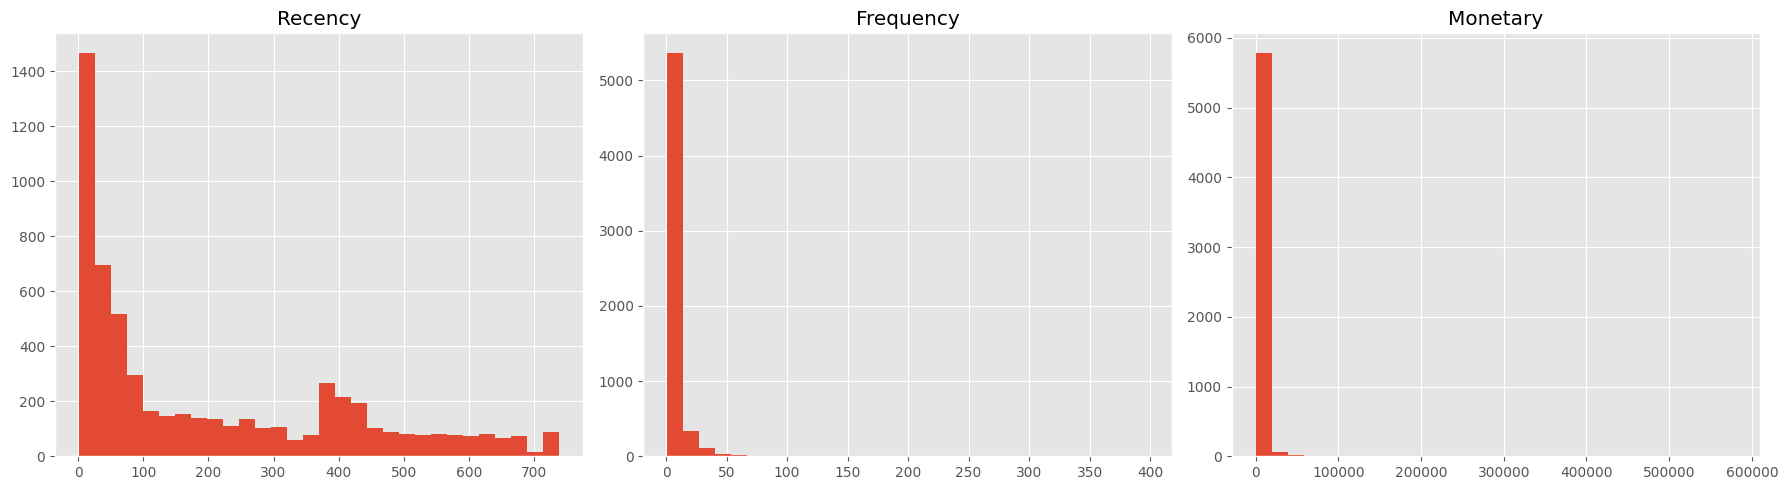

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, column in zip(axes, rfm.columns):
    ax.hist(rfm[column], bins=30)
    ax.set_title(column)

plt.tight_layout()
plt.show()

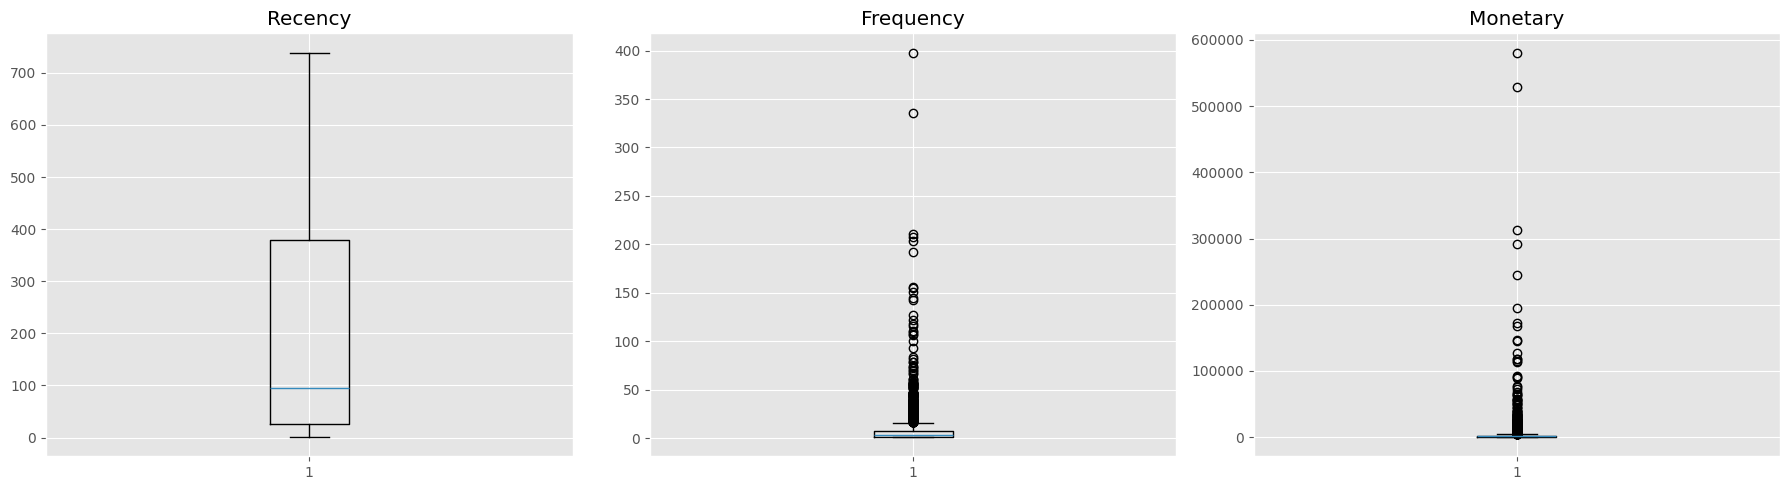

In [104]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for ax, column in zip(axes, rfm.columns):
    ax.boxplot(rfm[column])
    ax.set_title(column)

plt.tight_layout()
plt.show()

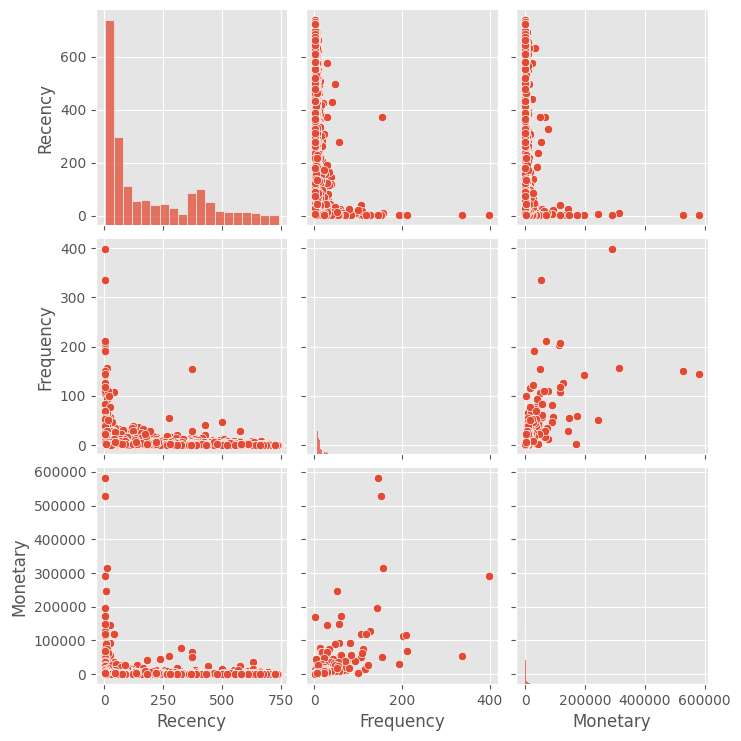

In [105]:
sns.pairplot(rfm)
plt.show()

In [106]:
corr = rfm.corr()

corr

,Recency,Frequency,Monetary
Recency,1.000000,-0.257013,-0.124956
Frequency,-0.257013,1.000000,0.627920
Monetary,-0.124956,0.627920,1.000000


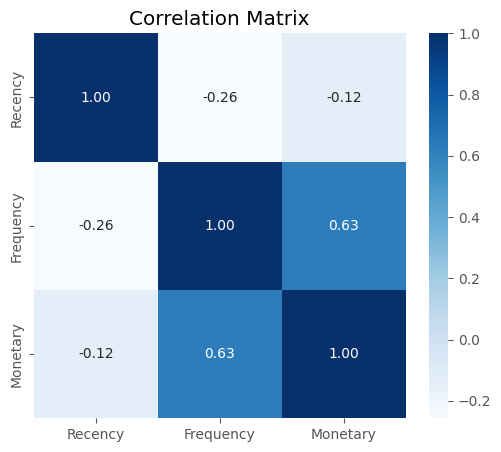

In [107]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [108]:
rfm.skew().sort_values(ascending=False)

,0
Monetary,25.070190
Frequency,12.639951
Recency,0.887198


In [109]:
rfm.kurtosis()

,0
Recency,-0.476970
Frequency,266.729382
Monetary,830.167745


In [112]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"{column}")
    print(f"Number of Outliers: {len(outliers)}")
    print(f"Percentage: {(len(outliers)/len(data))*100:.2f}%")
    print("-"*40)

In [113]:
for col in rfm.columns:
    detect_outliers_iqr(rfm, col)

Recency
Number of Outliers: 0
Percentage: 0.00%
----------------------------------------
Frequency
Number of Outliers: 427
Percentage: 7.26%
----------------------------------------
Monetary
Number of Outliers: 633
Percentage: 10.77%
----------------------------------------


In [114]:
rfm_transformed = rfm.copy()

In [115]:
import numpy as np

rfm_transformed["Recency"] = np.log1p(rfm_transformed["Recency"])
rfm_transformed["Frequency"] = np.log1p(rfm_transformed["Frequency"])
rfm_transformed["Monetary"] = np.log1p(rfm_transformed["Monetary"])

In [116]:
print("Original Skewness")
print(rfm.skew().round(2))

print("\nTransformed Skewness")
print(rfm_transformed.skew().round(2))

Original Skewness
Recency       0.89
Frequency    12.64
Monetary     25.07
dtype: float64

Transformed Skewness
Recency     -0.49
Frequency    1.00
Monetary     0.27
dtype: float64


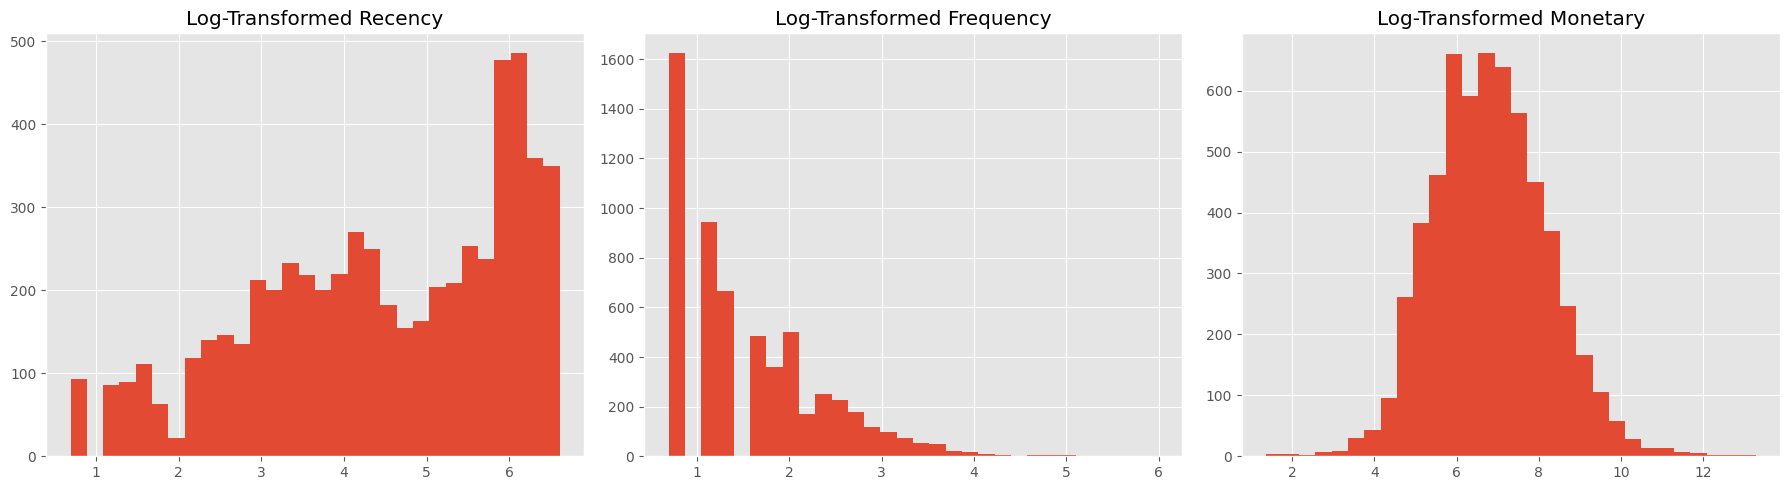

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, rfm_transformed.columns):
    ax.hist(rfm_transformed[column], bins=30)
    ax.set_title(f"Log-Transformed {column}")

plt.tight_layout()
plt.show()

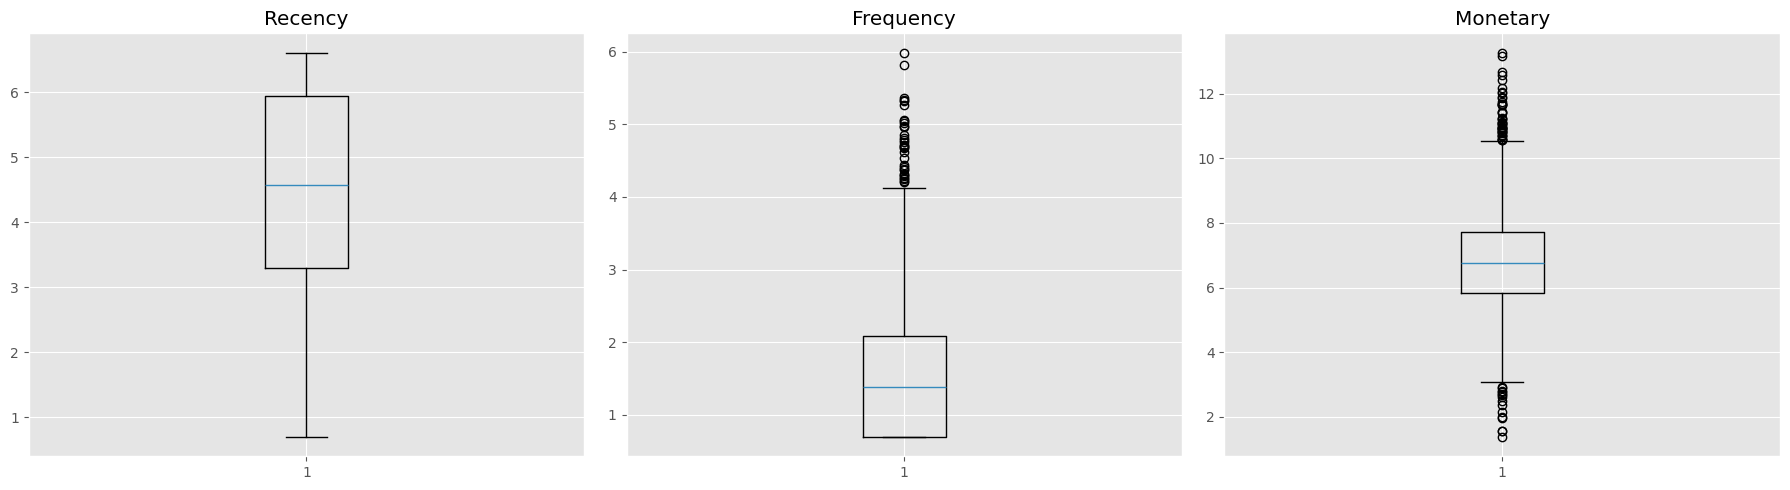

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, rfm_transformed.columns):
    ax.boxplot(rfm_transformed[column])
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_transformed)

In [120]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm_transformed.index,
    columns=rfm_transformed.columns
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.856701,1.254496,3.206219
12347.0,-2.151979,0.800166,1.215993
12348.0,-0.079138,0.299207,0.573185
12349.0,-0.935308,0.073946,1.139846
12350.0,0.824527,-1.058146,-0.723024


In [121]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.41,-1.06,-3.93
25%,-0.74,-1.06,-0.71
50%,0.08,-0.20,-0.04
75%,0.95,0.65,0.65
max,1.38,5.48,4.66


Finding the Optimal Number of Clusters

In [123]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [124]:
wcss = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

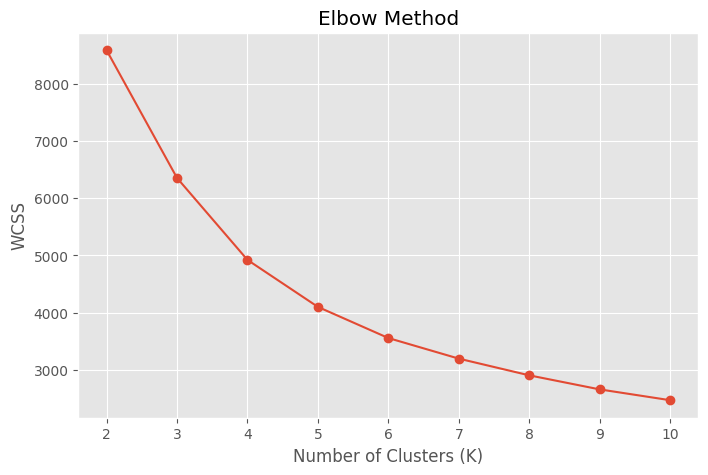

In [125]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.xticks(k_values)

plt.show()

In [126]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

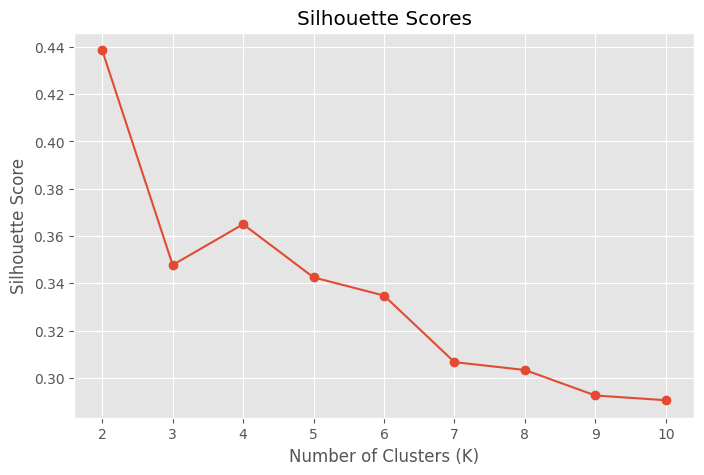

In [127]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)

plt.show()

In [128]:
evaluation = pd.DataFrame({
    "K": list(k_values),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
})

evaluation

,K,WCSS,Silhouette Score
0,2,8588.985343,0.438602
1,3,6354.343153,0.347745
2,4,4921.233345,0.364971
3,5,4099.106079,0.342496
4,6,3554.696269,0.334796
5,7,3194.500972,0.306636
6,8,2902.433885,0.303315
7,9,2656.562328,0.292524
8,10,2467.378466,0.290525


Train the Final K-Means Model

In [129]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

In [130]:
rfm["Cluster"] = clusters

In [131]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,2
12347.0,2,8,4921.53,2
12348.0,75,5,2019.40,3
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,0


In [132]:
cluster_sizes = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Number of Customers")
)

cluster_sizes

,Number of Customers
Cluster,
0,1973
1,1250
2,1196
3,1459


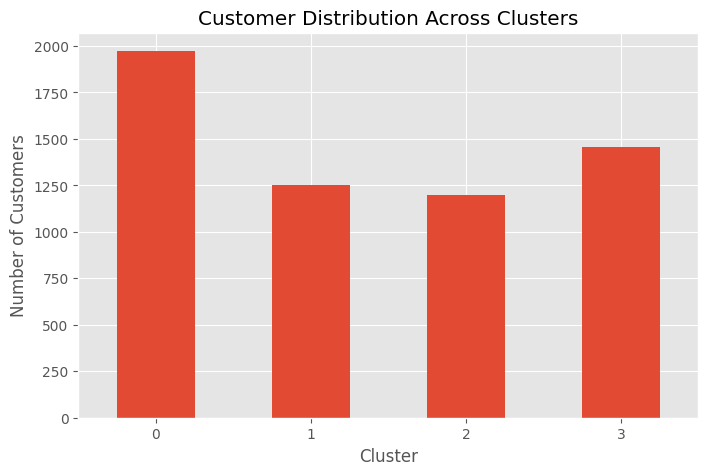

In [133]:
plt.figure(figsize=(8,5))

cluster_sizes.plot(kind="bar")

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [134]:
cluster_summary = (
    rfm
    .groupby("Cluster")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean"
    })
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,394.95,1.38,317.08
1,28.30,3.05,857.49
2,27.71,19.28,10731.16
3,230.07,5.06,1948.50


In [135]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

Visualize the Clusters with PCA

In [137]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)

rfm_pca = pca.fit_transform(rfm_scaled)

In [138]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

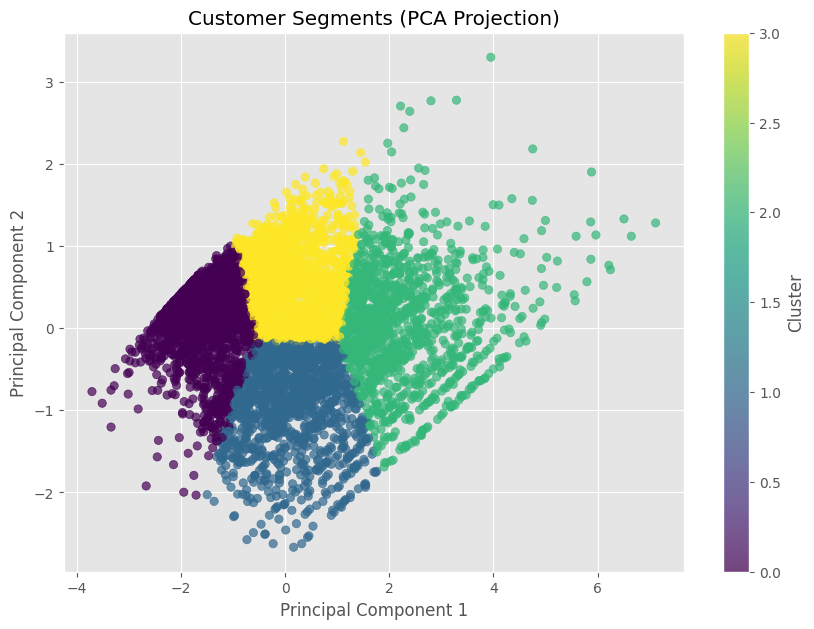

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA Projection)")

plt.colorbar(scatter, label="Cluster")

plt.show()

Feature Importance

In [140]:
explained_variance = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance Ratio": pca.explained_variance_ratio_
})

explained_variance

,Principal Component,Explained Variance Ratio
0,PC1,0.763567
1,PC2,0.187444


In [141]:
print(f"Cumulative Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

Cumulative Explained Variance: 95.10%


Save All The Details

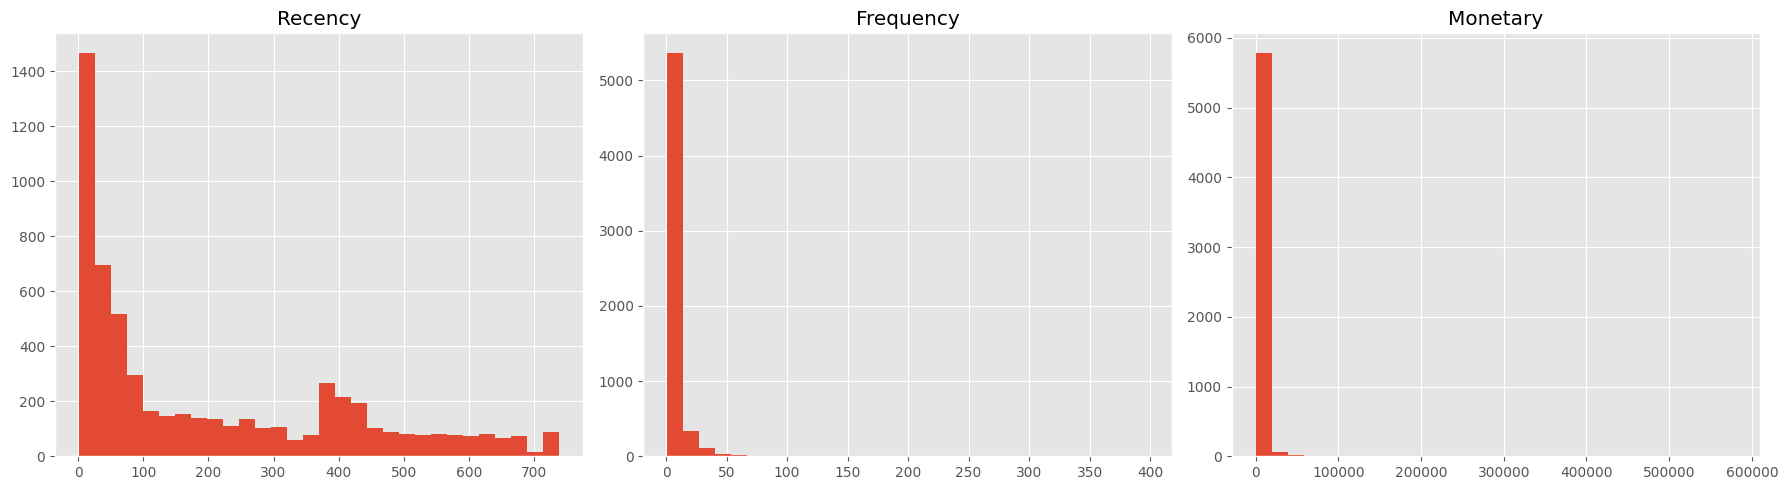

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, column in zip(axes, rfm.columns[:3]):
    ax.hist(rfm[column], bins=30)
    ax.set_title(column)

plt.tight_layout()
plt.savefig("rfm_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

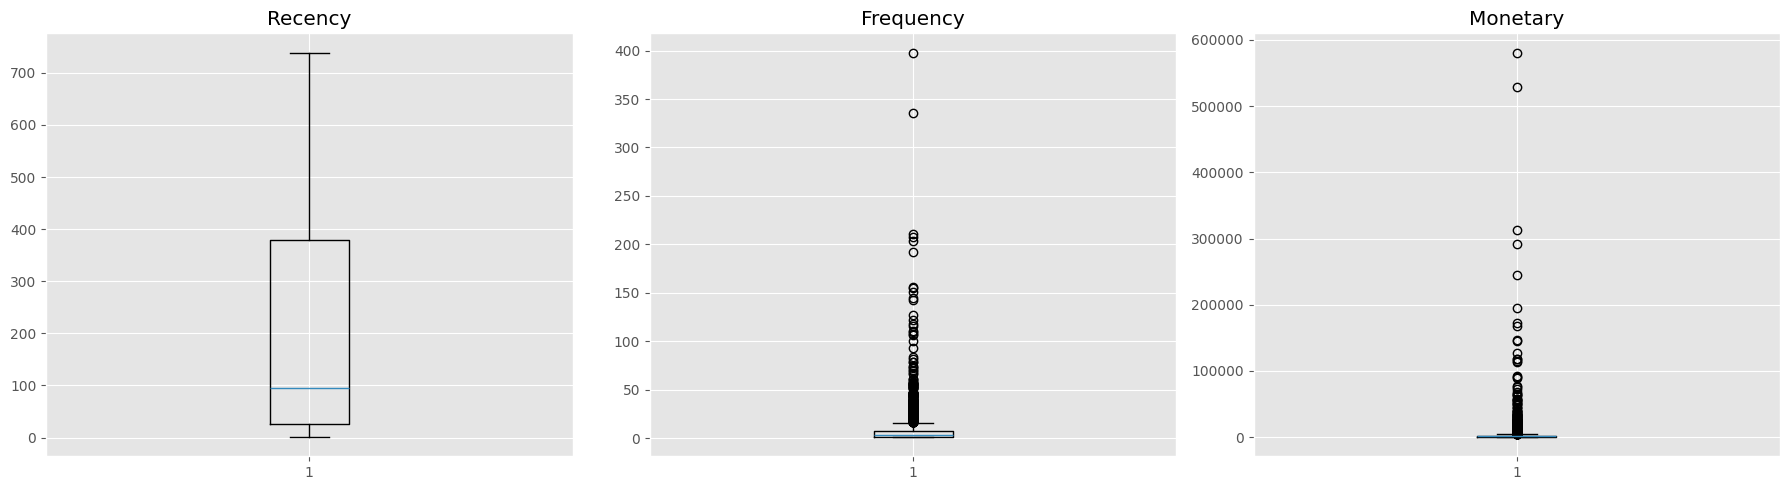

In [145]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for ax, column in zip(axes, rfm.columns[:3]):
    ax.boxplot(rfm[column])
    ax.set_title(column)

plt.tight_layout()
plt.savefig("rfm_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

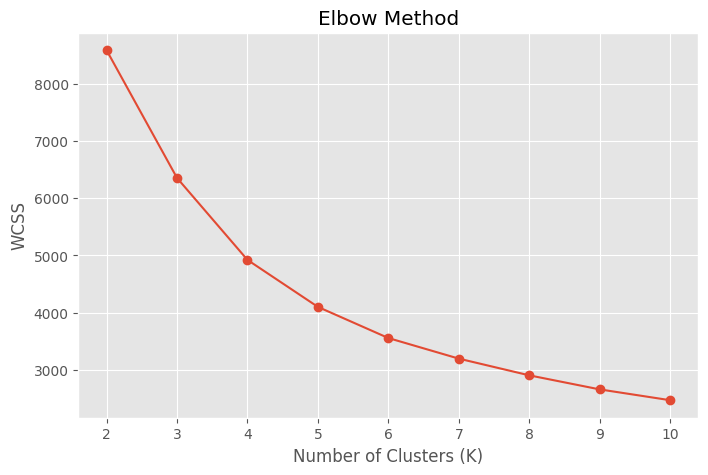

In [146]:
plt.figure(figsize=(8,5))

plt.plot(k_values, wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

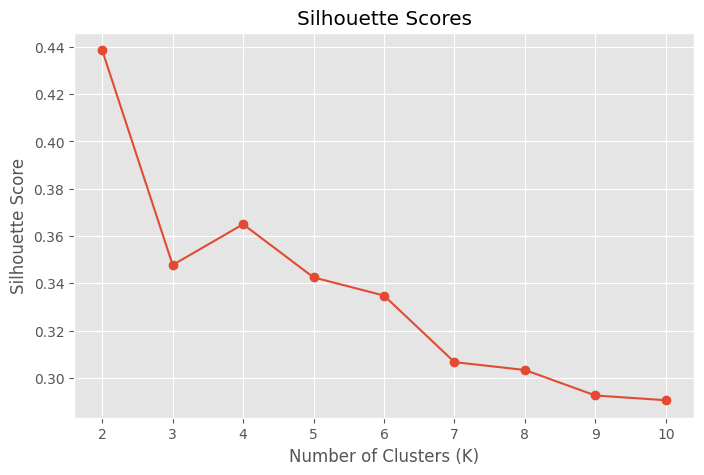

In [147]:
plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.savefig("silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()

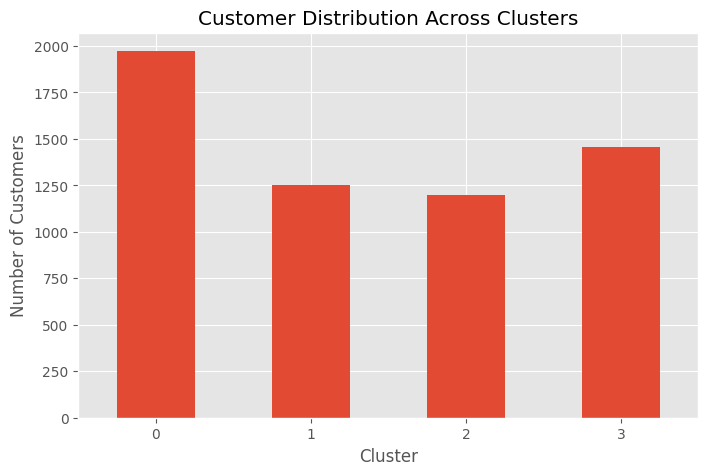

In [148]:
plt.figure(figsize=(8,5))

cluster_sizes.plot(kind="bar")

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.savefig("cluster_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

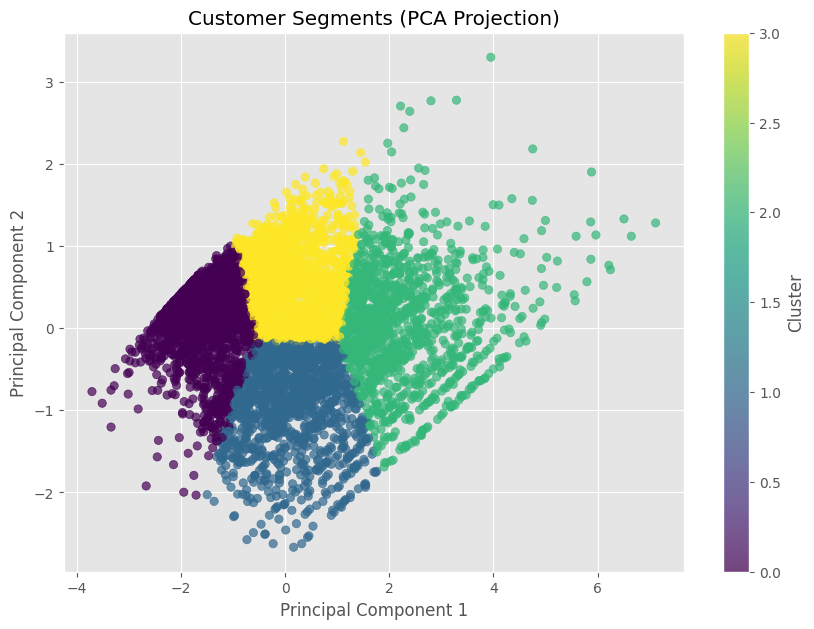

In [149]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA Projection)")

plt.colorbar(scatter, label="Cluster")

plt.savefig("pca_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [150]:
customer_segments = rfm.copy()

customer_segments.to_csv("customer_segments.csv")

cluster_summary.to_csv("cluster_summary.csv")

cleaning_summary.to_csv("cleaning_summary.csv", index=False)

evaluation.to_csv("evaluation_metrics.csv", index=False)

explained_variance.to_csv("pca_variance.csv", index=False)

In [151]:
import joblib

joblib.dump(scaler, "scaler.pkl")

joblib.dump(kmeans, "kmeans_model.pkl")

joblib.dump(pca, "pca.pkl")

['pca.pkl']

In [152]:
summary = f"""
Customer Segmentation using K-Means Clustering
==============================================

Dataset
-------
Online Retail Dataset

Total Customers:
{rfm.shape[0]}

Total Clusters:
4

Cluster Sizes
-------------
{cluster_sizes.to_string()}

Cluster Summary
---------------
{cluster_summary.to_string()}

Best K:
4

Evaluation Metrics
------------------
{evaluation.to_string(index=False)}

Project Pipeline
----------------
1. Data Loading
2. Data Cleaning
3. Feature Engineering (RFM)
4. Exploratory Data Analysis
5. Log Transformation
6. Standard Scaling
7. Elbow Method
8. Silhouette Score
9. K-Means Clustering
10. PCA Visualization
"""

with open("project_summary.txt", "w") as f:
    f.write(summary)

In [153]:
import os

files = sorted(os.listdir())

for file in files:
    print(file)

.config
cleaning_summary.csv
cluster_distribution.png
cluster_summary.csv
customer_segmentation_artifacts.zip
customer_segments.csv
drive
elbow_method.png
evaluation_metrics.csv
kmeans_model.pkl
online_retail_store_data.xlsx
pca.pkl
pca_clusters.png
pca_variance.csv
project_summary.txt
rfm_boxplots.png
rfm_histograms.png
sample_data
scaler.pkl
silhouette_scores.png


In [154]:
import zipfile
import os

files_to_zip = [
    "cleaning_summary.csv",
    "cluster_distribution.png",
    "cluster_summary.csv",
    "customer_segments.csv",
    "elbow_method.png",
    "evaluation_metrics.csv",
    "kmeans_model.pkl",
    "pca.pkl",
    "pca_clusters.png",
    "pca_variance.csv",
    "project_summary.txt",
    "rfm_boxplots.png",
    "rfm_histograms.png",
    "scaler.pkl",
    "silhouette_scores.png"
]

zip_filename = "customer_segmentation_portfolio_project.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
        else:
            print(f"Warning: {file} not found.")

print(f"ZIP file '{zip_filename}' created successfully!")

ZIP file 'customer_segmentation_portfolio_project.zip' created successfully!


In [155]:
from google.colab import files

files.download("customer_segmentation_portfolio_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>